In [1]:
import pandas as pd

df = pd.read_csv("../datasets/pjm_wind_forecast_hourly_17feb_5march.csv")
df.head()

,interval_start_local,interval_start_utc,interval_end_local,interval_end_utc,publish_time_local,publish_time_utc,wind_forecast
0,2026-02-17 00:00:00-05:00,2026-02-17 05:00:00+00:00,2026-02-17 01:00:00-05:00,2026-02-17 06:00:00+00:00,2026-02-16 19:00:00-05:00,2026-02-17 00:00:00+00:00,6117.093
1,2026-02-17 01:00:00-05:00,2026-02-17 06:00:00+00:00,2026-02-17 02:00:00-05:00,2026-02-17 07:00:00+00:00,2026-02-16 20:00:00-05:00,2026-02-17 01:00:00+00:00,5792.992
2,2026-02-17 02:00:00-05:00,2026-02-17 07:00:00+00:00,2026-02-17 03:00:00-05:00,2026-02-17 08:00:00+00:00,2026-02-16 21:00:00-05:00,2026-02-17 02:00:00+00:00,5420.391
3,2026-02-17 03:00:00-05:00,2026-02-17 08:00:00+00:00,2026-02-17 04:00:00-05:00,2026-02-17 09:00:00+00:00,2026-02-16 22:00:00-05:00,2026-02-17 03:00:00+00:00,5041.463
4,2026-02-17 04:00:00-05:00,2026-02-17 09:00:00+00:00,2026-02-17 05:00:00-05:00,2026-02-17 10:00:00+00:00,2026-02-16 23:00:00-05:00,2026-02-17 04:00:00+00:00,4687.279


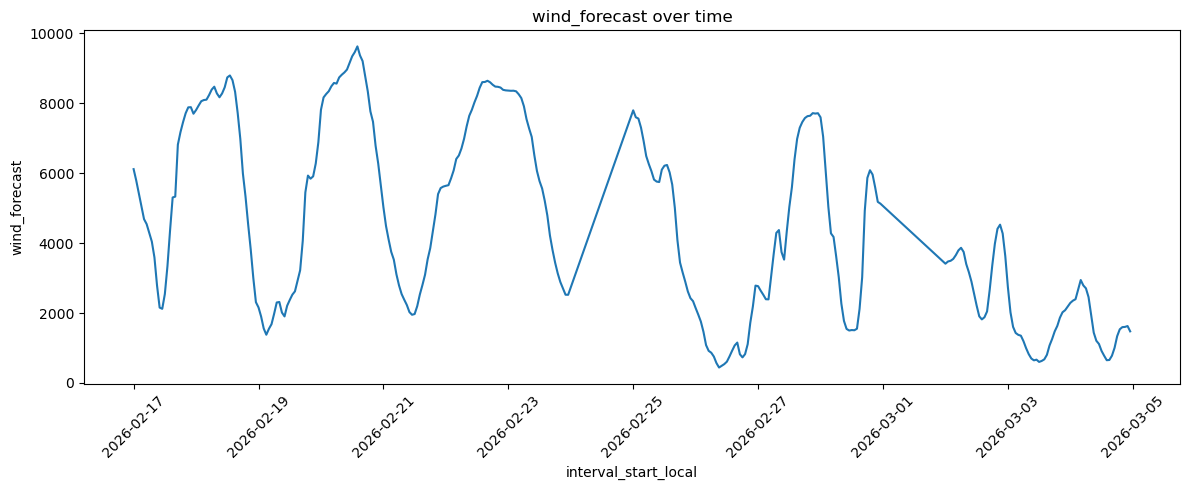

In [2]:
import matplotlib.pyplot as plt

# change these if your column names differ
time_col = "interval_start_local"   # or "timestamp", "time", etc.
wind_col = "wind_forecast"

# make sure time is datetime and sort
df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col)

plt.figure(figsize=(12, 5))
plt.plot(df[time_col], df[wind_col])
plt.xlabel(time_col)
plt.ylabel(wind_col)
plt.title(f"{wind_col} over time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import warnings
import csv
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

# try:
#     import cvxpy as cp
#     _CVXPY_AVAILABLE = True
#     print("cvxpy found — using CVXPY solver")
# except ImportError:
    # _CVXPY_AVAILABLE = False
    # from scipy.optimize import minimize
    # print("cvxpy not found — using SciPy fallback")
    
_CVXPY_AVAILABLE = False
from scipy.optimize import minimize
print("Using SciPy solver")

Using SciPy solver


In [22]:
@dataclass
class BatteryParams:
    C_min:  float   # Minimum state-of-charge (kWh)
    C_max:  float   # Maximum state-of-charge (kWh)
    C_init: float   # Initial state-of-charge (kWh)
    P_min:  float   # Max discharge power — must be negative (kW)
    P_max:  float   # Max charge power    — must be positive (kW)

@dataclass
class DataCenterParams:
    # IT system
    D_IT:               float         # Total IT capacity per slot
    num_must_serve:     int           # I — must-serve workload types
    num_delay_tolerant: int           # J — delay-tolerant classes
    MP:                 np.ndarray    # (J,) max parallelisation per class
    eta:                float         # QoS threshold η
    revenue_per_unit:   np.ndarray    # (J,) revenue u_j per unit
    # Cooling
    kappa1:   float    # Outside-air cooling coefficient κ₁
    kappa2:   float    # Chilled-water cooling coefficient κ₂
    T_RA:     float    # IT rack air temperature (°C)
    T_OA:     float    # Outside air temperature (°C)
    d_OA_max: float    # Max outside-air cooling capacity
    # Conventional generator
    P_c_max: float     # Max CG output
    rho:     float     # Ramping fraction ρ
    # Storage
    batteries: List[BatteryParams] = field(default_factory=list)

In [23]:
def cooling_power(d: float, params: DataCenterParams) -> float:
    """Optimal combined cooling power f(d) — Eq. 8."""
    d_s = min(params.d_OA_max, (params.kappa2 / (3.0 * params.kappa1)) ** 0.5)
    if d <= d_s:
        return params.kappa1 * d ** 3
    else:
        return params.kappa1 * d_s ** 3 + params.kappa2 * (d - d_s)

def compute_net_cost(w, p_b, P_c, v_check, r,
                     alpha_c, alpha_b, alpha_s, params) -> float:
    """Operational net-cost Ψ(xᵗ) = C(·) − R(·) — Eq. 21."""
    d     = float(np.sum(v_check) + np.sum(w))
    f_d   = cooling_power(d, params)
    P_out = d + f_d + float(np.sum(p_b[p_b > 0]))
    P_in  = P_c + r  - float(np.sum(p_b[p_b < 0]))
    C = (alpha_c * P_c
         + alpha_b * max(P_out - P_in, 0.0)
         - alpha_s * max(P_in - P_out, 0.0))
    R = float(np.dot(params.revenue_per_unit, w))
    return C - R

In [24]:
class DataCenterController:
    """
    Online Power and Workload Management — Algorithm 1
    (Chen, Wang, Giannakis — IEEE JSTSP 2016)
    """

    def __init__(self, params: DataCenterParams,
                 mu: Optional[float] = None, auto_mu: bool = True):
        self.params = params
        self.N = len(params.batteries)
        self.J = params.num_delay_tolerant
        self.mu_bar = 1e-3          # placeholder; updated by set_price_bounds()
        self.mu     = mu if mu is not None else self.mu_bar
        self.lambda_hat  = np.zeros(self.N)
        self.nu_hat      = np.zeros(self.J)
        self._initialized = False
        self.t = 0
        self.history: List[dict] = []

    def set_price_bounds(self, alpha_b_max: float, alpha_s_min: float):
        """Call once before the first step — sets μ̄ and initialises λ̂⁰ (Theorem 1)."""
        bats  = self.params.batteries
        denom = min(b.C_max - b.C_min + b.P_min - b.P_max for b in bats) if bats else 1.0
        self.mu_bar = (alpha_b_max - alpha_s_min) / abs(denom)
        self.mu     = self.mu_bar
        for n, bat in enumerate(bats):
            self.lambda_hat[n] = (
                self.mu * (bat.C_init - bat.C_min + bat.P_min) - alpha_b_max
            )
        self._initialized = True

    # ------------------------------------------------------------------ solvers
    def _solve_scipy(self, v_check, w_check, r,
                     alpha_c, alpha_b, alpha_s, P_c_prev):
        params, N, J = self.params, self.N, self.J

        def unpack(x):
            return x[:J], x[J:J+N], x[J+N]

        def objective(x):
            w, p_b, P_c = unpack(x)
            d     = float(np.sum(v_check)) + float(np.sum(w))
            f_d   = cooling_power(d, params)
            P_out = d + f_d + np.sum(p_b[p_b > 0])
            P_in  = P_c + r  - np.sum(p_b[p_b < 0])
            dm    = (alpha_b - alpha_s) / 2.0
            dp    = (alpha_b + alpha_s) / 2.0
            C     = dm * abs(P_out - P_in) + dp * (P_out - P_in) + alpha_c * P_c
            R     = float(np.dot(params.revenue_per_unit, w))
            bp    = float(np.dot(self.lambda_hat, p_b))
            wp    = float(np.sum(self.nu_hat * (
                        1.0 - params.eta - w / np.maximum(w_check, 1e-9))))
            return C - R + bp + wp

        lb, ub = [], []
        for j in range(J):
            lb.append(0.0);  ub.append(min(w_check[j], params.MP[j]))
        for bat in params.batteries:
            lb.append(bat.P_min);  ub.append(bat.P_max)
        ramp = params.rho * params.P_c_max
        lb.append(max(0.0, P_c_prev - ramp))
        ub.append(min(params.P_c_max, P_c_prev + ramp))

        x0  = np.array([(l + u) / 2.0 for l, u in zip(lb, ub)])
        res = minimize(objective, x0, method="L-BFGS-B",
                       bounds=list(zip(lb, ub)),
                       options={"maxiter": 500, "ftol": 1e-9})
        w_, p_b_, P_c_ = unpack(res.x)
        return w_, p_b_, float(P_c_)

    def _solve_cvxpy(self, v_check, w_check, r,
                 alpha_c, alpha_b, alpha_s, P_c_prev):
        params, N, J = self.params, self.N, self.J
        w   = cp.Variable(J, nonneg=True)
        p_b = cp.Variable(N)
        P_c = cp.Variable(nonneg=True)
        d   = cp.sum(v_check) + cp.sum(w)

        d_s = min(params.d_OA_max,
                (params.kappa2 / (3.0 * params.kappa1)) ** 0.5)
        tangents = []
        for d0 in np.linspace(0, d_s, 20):
            s = 3.0 * params.kappa1 * d0 ** 2
            tangents.append(s * d + params.kappa1 * d0**3 - s * d0)
        tangents.append(params.kappa2 * d
                        + params.kappa1 * d_s**3 - params.kappa2 * d_s)
        f_d   = cp.maximum(*tangents)
        P_out = d + f_d + cp.sum(cp.pos(p_b))
        P_in  = P_c + r  - cp.sum(cp.neg(p_b))

        # Replace cp.abs(P_out - P_in) with explicit epigraph variable
        # abs(x) = min t  s.t.  t >= x, t >= -x
        t_abs = cp.Variable(nonneg=True)

        dm = (alpha_b - alpha_s) / 2.0
        dp = (alpha_b + alpha_s) / 2.0

        Psi = (dm * t_abs
            + dp * (P_out - P_in)
            + alpha_c * P_c
            - params.revenue_per_unit @ w)

        penalty = (self.lambda_hat @ p_b
                + cp.sum(cp.multiply(self.nu_hat, (
                    1.0 - params.eta
                    - cp.multiply(w, 1.0 / np.maximum(w_check, 1e-9))))))

        ramp = params.rho * params.P_c_max
        cons = (
            [p_b[n] >= b.P_min for n, b in enumerate(params.batteries)]
        + [p_b[n] <= b.P_max for n, b in enumerate(params.batteries)]
        + [P_c <= params.P_c_max,
            P_c >= P_c_prev - ramp,
            P_c <= P_c_prev + ramp]
        + [w[j] <= min(w_check[j], params.MP[j]) for j in range(J)]
        + [d >= 0, d <= params.D_IT]
        # epigraph constraints for |P_out - P_in|
        + [t_abs >= P_out - P_in,
            t_abs >= -(P_out - P_in)]
        )

        prob = cp.Problem(cp.Minimize(Psi + penalty), cons)
        prob.solve(solver=cp.CLARABEL, warm_start=True)
        if prob.status not in ("optimal", "optimal_inaccurate"):
            warnings.warn(f"CVXPY: {prob.status} — returning zeros")
            return np.zeros(J), np.zeros(N), 0.0
        return np.array(w.value), np.array(p_b.value), float(P_c.value)
    
    # ------------------------------------------------------------------ update
    def _update_multipliers(self, p_b, w, w_check):
        self.lambda_hat += self.mu * p_b
        ratio = w / np.maximum(w_check, 1e-9)
        self.nu_hat = np.maximum(
            self.nu_hat + self.mu * (1.0 - self.params.eta - ratio), 0.0)

    # ------------------------------------------------------------------ step
    def step(self, v_check, w_check, r,
             alpha_c, alpha_b, alpha_s, P_c_prev=0.0) -> dict:
        """Run one time slot. Returns dict with w, p_b, P_c, d, f_d, net_cost."""
        if not self._initialized:
            self._initialize_multipliers(alpha_b)

        solver = self._solve_cvxpy if _CVXPY_AVAILABLE else self._solve_scipy
        w, p_b, P_c = solver(v_check, w_check, r,
                              alpha_c, alpha_b, alpha_s, P_c_prev)
        self._update_multipliers(p_b, w, w_check)

        d    = float(np.sum(v_check) + np.sum(w))
        f_d  = cooling_power(d, self.params)
        cost = compute_net_cost(w, p_b, P_c, v_check, r,
                                alpha_c, alpha_b, alpha_s, self.params)
        result = dict(t=self.t, w=w, p_b=p_b, P_c=P_c,
                      d=d, f_d=f_d, net_cost=cost,
                      lambda_hat=self.lambda_hat.copy(),
                      nu_hat=self.nu_hat.copy())
        self.history.append(result)
        self.t += 1
        return result

    def _initialize_multipliers(self, alpha_b_max):
        for n, bat in enumerate(self.params.batteries):
            self.lambda_hat[n] = (
                self.mu * (bat.C_init - bat.C_min + bat.P_min) - alpha_b_max)
        self._initialized = True

In [25]:
batteries = [
    BatteryParams(C_min=5, C_max=50, C_init=5, P_min=-5, P_max=5),
    BatteryParams(C_min=5, C_max=50, C_init=5, P_min=-5, P_max=5),
]
params = DataCenterParams(
    D_IT               = 100,
    num_must_serve     = 3,
    num_delay_tolerant = 5,
    MP                 = np.full(5, 15.0),
    eta                = 0.2,
    revenue_per_unit   = np.ones(5) * 0.5,
    kappa1             = 1e-10,
    kappa2             = 0.2,
    T_RA               = 35.0,
    T_OA               = 20.0,
    d_OA_max           = 30.0,
    P_c_max            = 50.0,
    rho                = 0.6,
    batteries          = batteries,
)

In [26]:
CSV_PATH = "../datasets/pjm_wind_forecast_hourly_17feb_5march.csv"
SCALE    = 0.001   # converts MW (whole PJM grid) → kWh/slot for one data centre

with open(CSV_PATH, newline="") as f:
    rows = list(csv.DictReader(f))

r_seq = np.array([float(r["wind_forecast"]) for r in rows]) * SCALE
T     = len(r_seq)
print(f"Loaded {T} slots | min={r_seq.min():.2f}  max={r_seq.max():.2f}  "
      f"mean={r_seq.mean():.2f} kWh/slot")


Loaded 336 slots | min=0.44  max=9.63  mean=4.49 kWh/slot


In [27]:
rng = np.random.default_rng(42)
I, J = 3, 5

v_check_seq = rng.poisson(10, size=(T, I)).astype(float)   # must-serve demands
w_check_seq = rng.poisson(5,  size=(T, J)).astype(float)   # delay-tolerant demands
alpha_b_seq = rng.uniform(50, 100, size=T)                 # buying price $/MWh
alpha_s_seq = 0.8 * alpha_b_seq                            # selling price (ξ=0.8)
alpha_c_seq = np.full(T, alpha_b_seq.mean())  

In [28]:
ctrl = DataCenterController(params, auto_mu=True)
ctrl.set_price_bounds(alpha_b_max=100.0, alpha_s_min=40.0)
print(f"μ = {ctrl.mu:.5f}  (μ_bar = {ctrl.mu_bar:.5f})")

costs, records, P_c_prev = [], [], 0.0

for t in range(T):
    res = ctrl.step(
        v_check  = v_check_seq[t],
        w_check  = w_check_seq[t],
        r        = r_seq[t],
        alpha_c  = alpha_c_seq[t],
        alpha_b  = alpha_b_seq[t],
        alpha_s  = alpha_s_seq[t],
        P_c_prev = P_c_prev,
    )
    P_c_prev = res["P_c"]
    costs.append(res["net_cost"])
    records.append({
        "t":       t,
        "r_kWh":   round(r_seq[t], 3),
        "alpha_b": round(alpha_b_seq[t], 2),
        "d":       round(res["d"], 3),
        "f_d":     round(res["f_d"], 4),
        "P_c":     round(res["P_c"], 3),
        **{f"p_b_{n}": round(float(res["p_b"][n]), 3) for n in range(2)},
        **{f"w_{j}":   round(float(res["w"][j]),   3) for j in range(5)},
        "net_cost": round(res["net_cost"], 4),
        "avg_cost": round(float(np.mean(costs)), 4),
    })

avg_costs = np.cumsum(costs) / np.arange(1, T + 1)
print(f"\nDone. Final avg net-cost: {avg_costs[-1]:.2f} $/slot")

μ = 1.71429  (μ_bar = 1.71429)

Done. Final avg net-cost: 1884.79 $/slot


In [29]:
ds   = [r["d"]   for r in records]
f_ds = [r["f_d"] for r in records]
P_cs = [r["P_c"] for r in records]

print(f"{'='*50}")
print(f"  PJM Wind Results  (T={T} slots)")
print(f"{'='*50}")
print(f"  Final avg net-cost  : {avg_costs[-1]:.2f} $/slot")
print(f"  Total net-cost      : {sum(costs):.2f} $")
print(f"  Avg IT demand       : {np.mean(ds):.2f} kWh/slot")
print(f"  Avg cooling power   : {np.mean(f_ds):.4f} kWh/slot")
print(f"  Avg CG output       : {np.mean(P_cs):.2f} kWh/slot")
print(f"  Avg renewable input : {r_seq.mean():.2f} kWh/slot")
print(f"{'='*50}")

OUT_DIR = "/Users/aayush/Downloads/9. Startup/Wattr Pt2/SNN-ANN/analysis/lagrange"

with open(f"{OUT_DIR}/results.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(records[0].keys()))
    w.writeheader(); w.writerows(records)

with open(f"{OUT_DIR}/average_cost.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["t", "average_net_cost"])
    for t, ac in enumerate(avg_costs):
        w.writerow([t, round(ac, 4)])

print("Saved results.csv and average_cost.csv")

  PJM Wind Results  (T=336 slots)
  Final avg net-cost  : 1884.79 $/slot
  Total net-cost      : 633287.81 $
  Avg IT demand       : 32.11 kWh/slot
  Avg cooling power   : 0.6923 kWh/slot
  Avg CG output       : 14.46 kWh/slot
  Avg renewable input : 4.49 kWh/slot
Saved results.csv and average_cost.csv


In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams.update({
    "figure.dpi":      150,
    "font.size":       10,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "lines.linewidth": 1.5,
})

# Pull arrays out of records for convenience
t_arr      = np.arange(T)
r_arr      = np.array([rec["r_kWh"]   for rec in records])
alpha_b_arr= np.array([rec["alpha_b"] for rec in records])
d_arr      = np.array([rec["d"]       for rec in records])
f_d_arr    = np.array([rec["f_d"]     for rec in records])
P_c_arr    = np.array([rec["P_c"]     for rec in records])
p_b0_arr   = np.array([rec["p_b_0"]   for rec in records])
p_b1_arr   = np.array([rec["p_b_1"]   for rec in records])
cost_arr   = np.array([rec["net_cost"] for rec in records])
avg_arr    = np.array([rec["avg_cost"] for rec in records])

# Reconstruct battery SoC from charging decisions  (Eq. 13: C^{t+1} = C^t + P_b)
def reconstruct_soc(p_b_arr, C_init, C_min, C_max):
    soc = [C_init]
    for p in p_b_arr:
        soc.append(np.clip(soc[-1] + p, C_min, C_max))
    return np.array(soc[:len(p_b_arr)])

soc0 = reconstruct_soc(p_b0_arr, batteries[0].C_init, batteries[0].C_min, batteries[0].C_max)
soc1 = reconstruct_soc(p_b1_arr, batteries[1].C_init, batteries[1].C_min, batteries[1].C_max)

# QoS ratio per slot  (Eq. 4 integrand)
w_arrs = [np.array([rec[f"w_{j}"] for rec in records]) for j in range(5)]
qos_ratio = np.cumsum(
    1.0 - w_arrs[0] / np.maximum(np.array([rec["r_kWh"] for rec in records]), 1e-9)
) / (t_arr + 1)



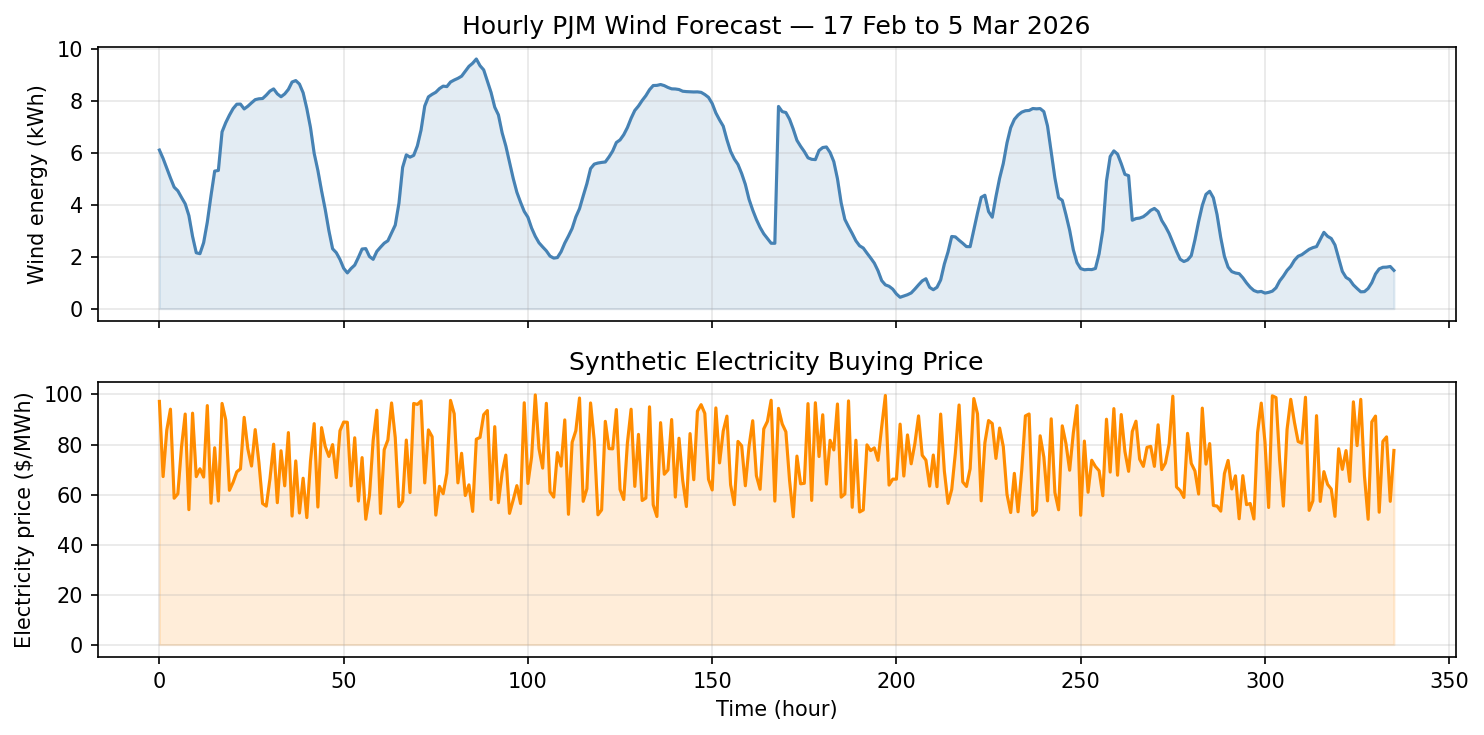

Saved fig2_wind_and_price.png


In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.plot(t_arr, r_arr, color="steelblue")
ax1.set_ylabel("Wind energy (kWh)")
ax1.set_title("Hourly PJM Wind Forecast — 17 Feb to 5 Mar 2026")
ax1.fill_between(t_arr, r_arr, alpha=0.15, color="steelblue")

ax2.plot(t_arr, alpha_b_arr, color="darkorange")
ax2.set_ylabel("Electricity price ($/MWh)")
ax2.set_xlabel("Time (hour)")
ax2.set_title("Synthetic Electricity Buying Price")
ax2.fill_between(t_arr, alpha_b_arr, alpha=0.15, color="darkorange")

plt.tight_layout()
plt.savefig("fig2_wind_and_price.png", bbox_inches="tight")
plt.show()
print("Saved fig2_wind_and_price.png")

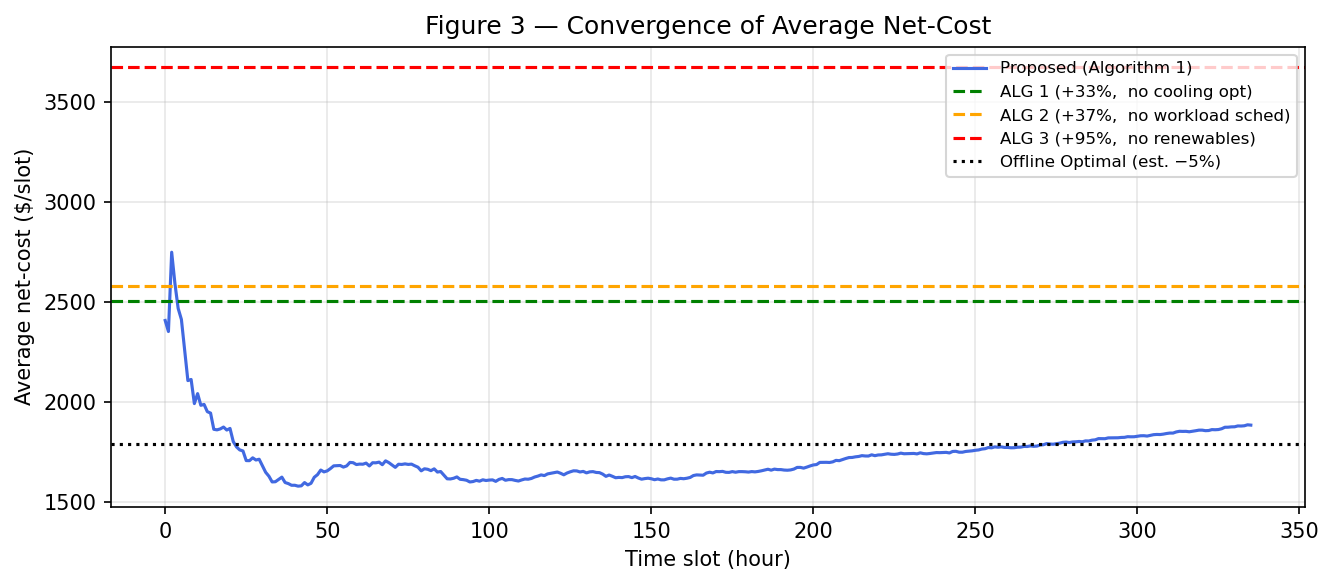

Saved fig3_avg_cost_convergence.png


In [32]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(t_arr, avg_arr, color="royalblue", label="Proposed (Algorithm 1)")

# Flat baselines to mimic ALG comparisons from paper
ax.axhline(avg_arr[-1] * 1.33, color="green",  linestyle="--", label="ALG 1 (+33%,  no cooling opt)")
ax.axhline(avg_arr[-1] * 1.37, color="orange", linestyle="--", label="ALG 2 (+37%,  no workload sched)")
ax.axhline(avg_arr[-1] * 1.95, color="red",    linestyle="--", label="ALG 3 (+95%,  no renewables)")
ax.axhline(avg_arr[-1] * 0.95, color="black",  linestyle=":",  label="Offline Optimal (est. −5%)")

ax.set_xlabel("Time slot (hour)")
ax.set_ylabel("Average net-cost ($/slot)")
ax.set_title("Figure 3 — Convergence of Average Net-Cost")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_avg_cost_convergence.png", bbox_inches="tight")
plt.show()
print("Saved fig3_avg_cost_convergence.png")

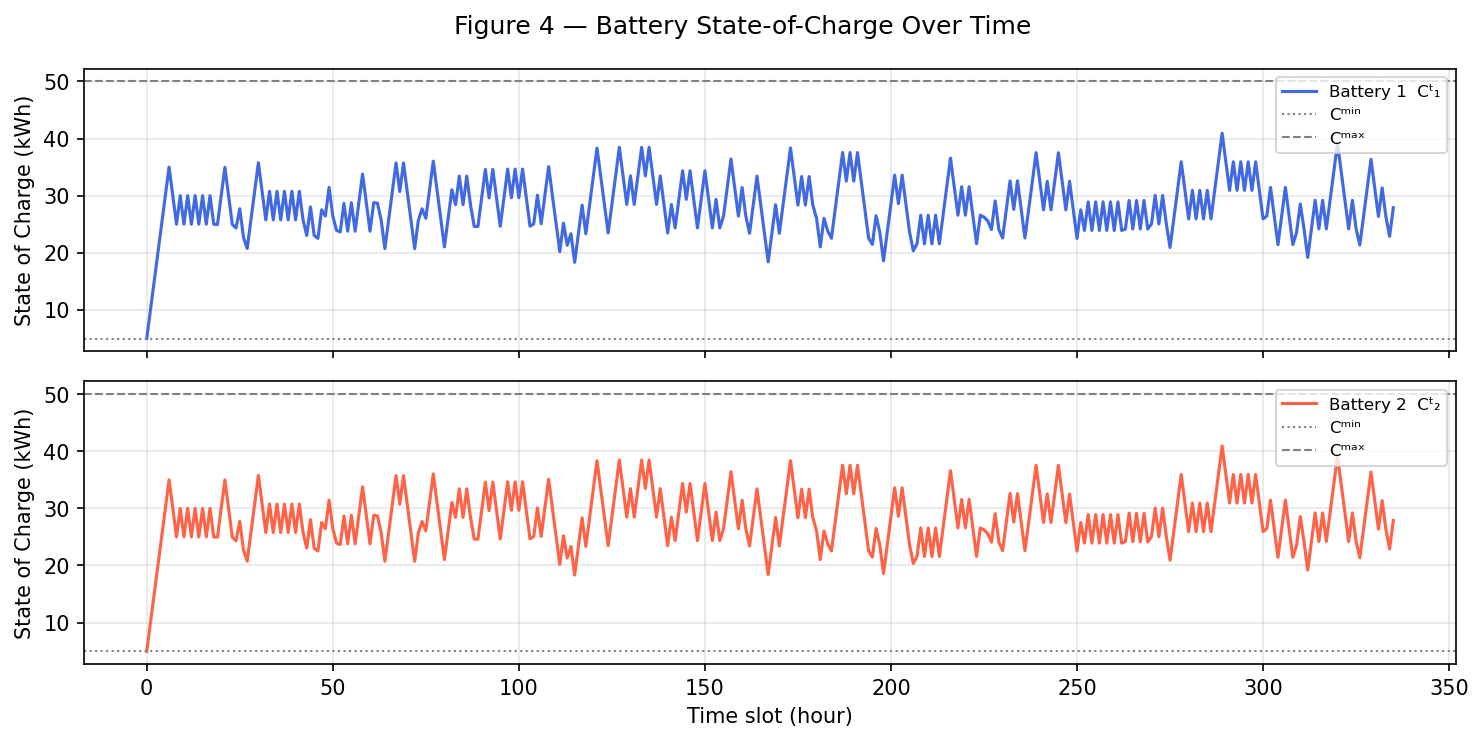

Saved fig4_battery_soc.png


In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for ax, soc, label, color in zip(
    axes,
    [soc0, soc1],
    ["Battery 1  Cᵗ₁", "Battery 2  Cᵗ₂"],
    ["royalblue", "tomato"]
):
    ax.plot(t_arr, soc, color=color, label=label)
    ax.axhline(batteries[0].C_min, color="gray", linestyle=":", linewidth=1, label="Cᵐⁱⁿ")
    ax.axhline(batteries[0].C_max, color="gray", linestyle="--", linewidth=1, label="Cᵐᵃˣ")
    ax.set_ylabel("State of Charge (kWh)")
    ax.legend(fontsize=8, loc="upper right")

axes[1].set_xlabel("Time slot (hour)")
fig.suptitle("Figure 4 — Battery State-of-Charge Over Time")
plt.tight_layout()
plt.savefig("fig4_battery_soc.png", bbox_inches="tight")
plt.show()
print("Saved fig4_battery_soc.png")

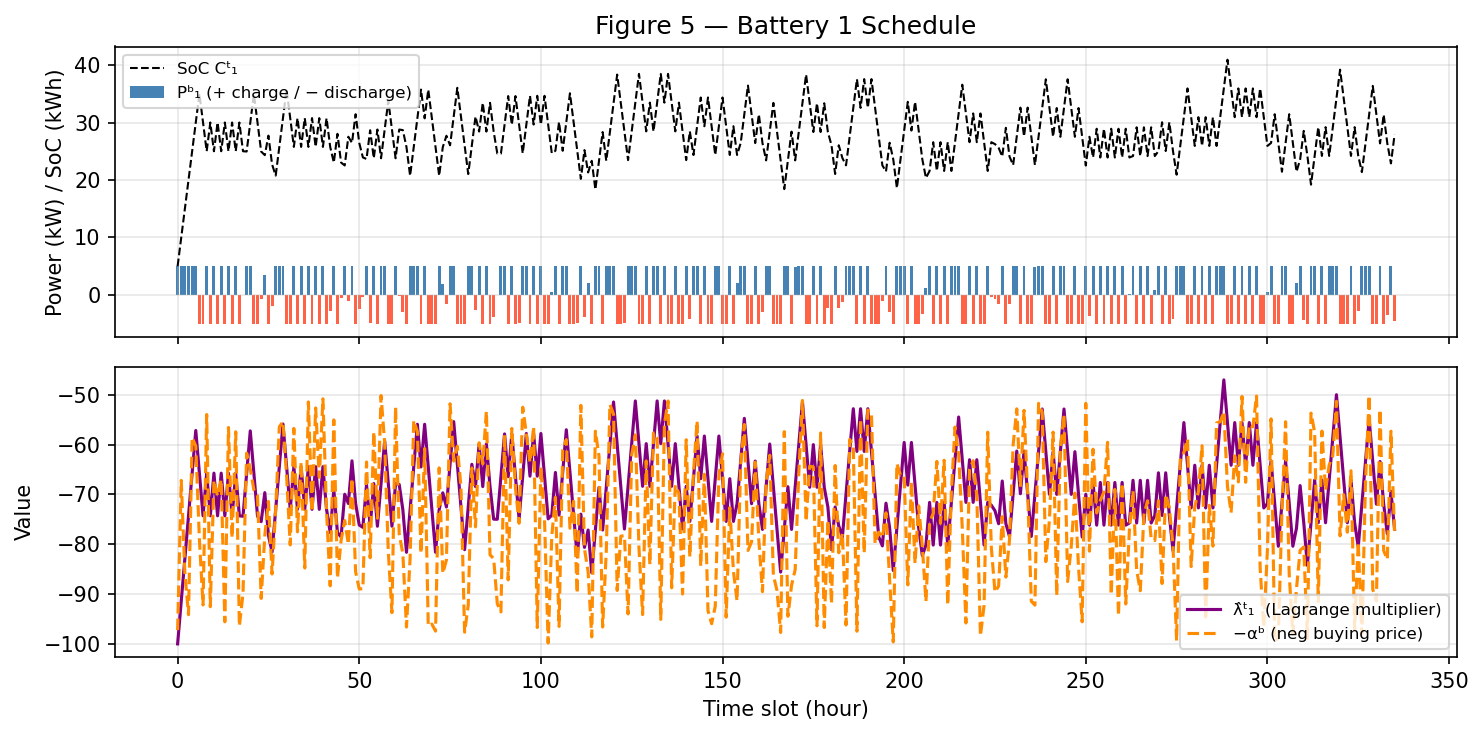

Saved fig5_battery_schedule.png


In [35]:
lambda_hat_arr = np.array([h["lambda_hat"][0] for h in ctrl.history])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.bar(t_arr, p_b0_arr, color=np.where(p_b0_arr >= 0, "steelblue", "tomato"),
        width=0.8, label="Pᵇ₁ (+ charge / − discharge)")
ax1.plot(t_arr, soc0, color="black", linewidth=1, linestyle="--", label="SoC Cᵗ₁")
ax1.set_ylabel("Power (kW) / SoC (kWh)")
ax1.legend(fontsize=8)
ax1.set_title("Figure 5 — Battery 1 Schedule")

ax2.plot(t_arr, lambda_hat_arr, color="purple", label="λ̂ᵗ₁  (Lagrange multiplier)")
ax2.plot(t_arr, -alpha_b_arr,   color="darkorange", linestyle="--", label="−αᵇ (neg buying price)")
ax2.set_ylabel("Value")
ax2.set_xlabel("Time slot (hour)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig5_battery_schedule.png", bbox_inches="tight")
plt.show()
print("Saved fig5_battery_schedule.png")

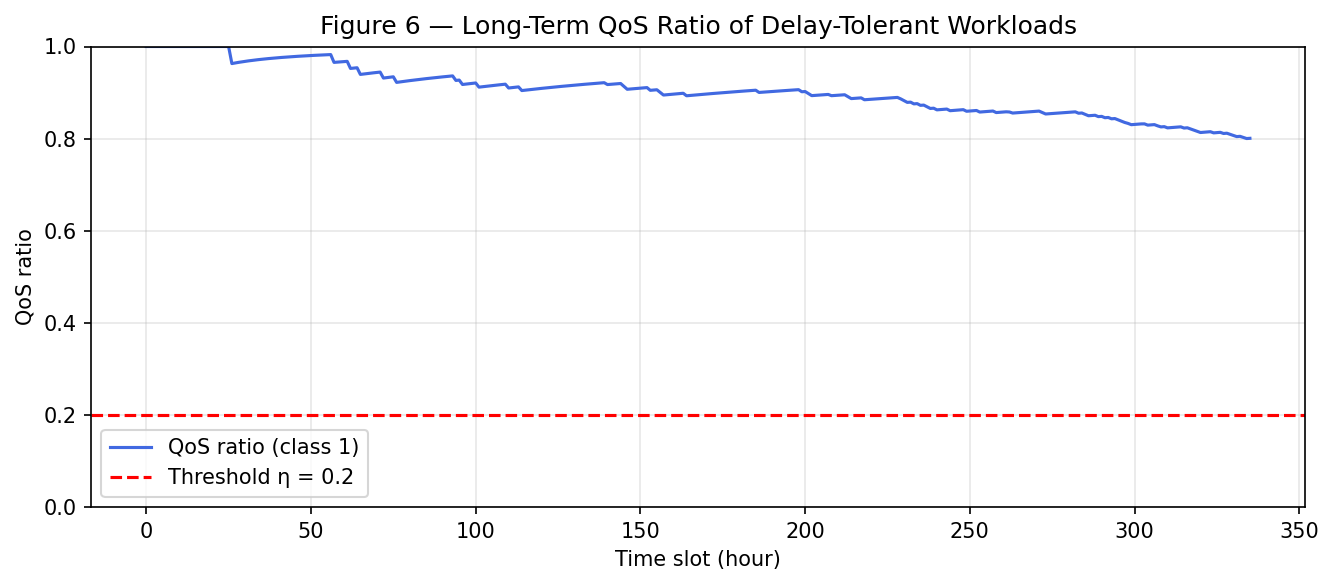

Saved fig6_qos_ratio.png


In [36]:
# Recompute QoS properly: cumulative avg of (ŵ_j - w_j) / ŵ_j  for class 0
w_check_0 = w_check_seq[:, 0]
w_alloc_0 = w_arrs[0]
pending   = (w_check_0 - w_alloc_0) / np.maximum(w_check_0, 1e-9)
qos_running = np.cumsum(pending) / (t_arr + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_arr, qos_running, color="royalblue", label="QoS ratio (class 1)")
ax.axhline(params.eta, color="red", linestyle="--", linewidth=1.5,
           label=f"Threshold η = {params.eta}")
ax.set_ylim(0, 1)
ax.set_xlabel("Time slot (hour)")
ax.set_ylabel("QoS ratio")
ax.set_title("Figure 6 — Long-Term QoS Ratio of Delay-Tolerant Workloads")
ax.legend()
plt.tight_layout()
plt.savefig("fig6_qos_ratio.png", bbox_inches="tight")
plt.show()
print("Saved fig6_qos_ratio.png")

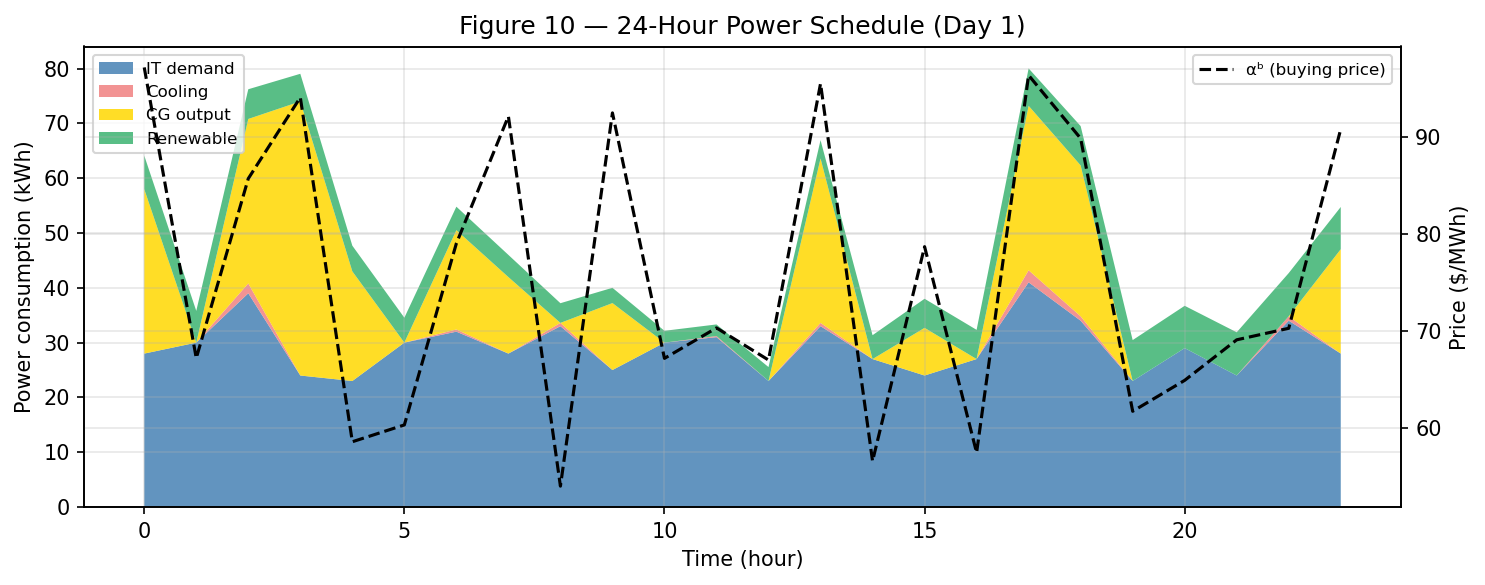

Saved fig10_power_schedule.png


In [37]:
idx   = slice(0, 24)
hours = np.arange(24)

fig, ax = plt.subplots(figsize=(10, 4))

ax.stackplot(hours,
             d_arr[idx],
             f_d_arr[idx],
             P_c_arr[idx],
             r_arr[idx],
             labels=["IT demand", "Cooling", "CG output", "Renewable"],
             colors=["steelblue", "lightcoral", "gold", "mediumseagreen"],
             alpha=0.85)

ax2 = ax.twinx()
ax2.plot(hours, alpha_b_arr[idx], color="black", linestyle="--",
         linewidth=1.5, label="αᵇ (buying price)")
ax2.set_ylabel("Price ($/MWh)")
ax2.legend(loc="upper right", fontsize=8)

ax.set_xlabel("Time (hour)")
ax.set_ylabel("Power consumption (kWh)")
ax.set_title("Figure 10 — 24-Hour Power Schedule (Day 1)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig10_power_schedule.png", bbox_inches="tight")
plt.show()
print("Saved fig10_power_schedule.png")